# Laboratorio 6 – K Nearest Neighbors (KNN)


## Configuración e Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

import math

# Semilla global
SEED = 42
np.random.seed(SEED)

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías importadas correctamente')

Librerías importadas correctamente


## Carga y Preprocesamiento de Datos


In [2]:
# Cargar datos
result = pyreadr.read_r('listings.RData')
data = result['listings'].copy()
print(f'Dataset original: {data.shape[0]} filas, {data.shape[1]} columnas')

# Limpieza del precio (mismo proceso de entregas anteriores)
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

# Variable categórica del precio (terciles)
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

print(f'\nDatos con precio válido: {data.shape[0]} filas')
print(f'\nDistribución de categorías de precio:')
print(data['price_cat'].value_counts().sort_index())
print(f'\nEstadísticas del precio:')
print(data['price'].describe())

Dataset original: 171748 filas, 80 columnas

Datos con precio válido: 72233 filas

Distribución de categorías de precio:
price_cat
barata    24092
media     24135
cara      24006
Name: count, dtype: int64

Estadísticas del precio:
count    72233.000000
mean       237.380685
std        178.085148
min          8.000000
25%        117.000000
50%        184.000000
75%        297.000000
max        999.000000
Name: price, dtype: float64


In [3]:
# Selección de features (mismas que en entregas anteriores)
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
            'minimum_nights', 'number_of_reviews', 'review_scores_rating']

X = data[features].copy()
X = X.dropna()

# Variables respuesta
y_reg = data.loc[X.index, 'price'].copy()       # Regresión
y_clf = data.loc[X.index, 'price_cat'].copy()    # Clasificación

print(f'Observaciones después de limpieza: {X.shape[0]}')
print(f'Features seleccionadas: {features}')
print(f'\nValores faltantes por feature:')
print(X.isnull().sum())

Observaciones después de limpieza: 60589
Features seleccionadas: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating']

Valores faltantes por feature:
accommodates            0
bathrooms               0
bedrooms                0
beds                    0
minimum_nights          0
number_of_reviews       0
review_scores_rating    0
dtype: int64


In [4]:
# División entrenamiento/prueba - MISMA que entregas anteriores
# 70% entrenamiento, 30% prueba, random_state=42
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=SEED
)

# Para clasificación, mismos índices
y_train_clf = y_clf[X_train.index]
y_test_clf = y_clf[X_test.index]

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]*100:.1f}%)')
print(f'\nDistribución de categorías en entrenamiento:')
print(y_train_clf.value_counts().sort_index())
print(f'\nDistribución de categorías en prueba:')
print(y_test_clf.value_counts().sort_index())

Conjunto de entrenamiento: 42412 muestras (70.0%)
Conjunto de prueba: 18177 muestras (30.0%)

Distribución de categorías en entrenamiento:
price_cat
barata    14864
media     14254
cara      13294
Name: count, dtype: int64

Distribución de categorías en prueba:
price_cat
barata    6264
media     6220
cara      5693
Name: count, dtype: int64


## Normalización de los Datos



In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos normalizados con StandardScaler')
print(f'\nMedia de features en entrenamiento (post-scaling):')
print(pd.Series(X_train_scaled.mean(axis=0), index=features).round(6))
print(f'\nDesviación estándar en entrenamiento (post-scaling):')
print(pd.Series(X_train_scaled.std(axis=0), index=features).round(6))

Datos normalizados con StandardScaler

Media de features en entrenamiento (post-scaling):
accommodates           -0.0
bathrooms               0.0
bedrooms               -0.0
beds                    0.0
minimum_nights          0.0
number_of_reviews       0.0
review_scores_rating   -0.0
dtype: float64

Desviación estándar en entrenamiento (post-scaling):
accommodates            1.0
bathrooms               1.0
bedrooms                1.0
beds                    1.0
minimum_nights          1.0
number_of_reviews       1.0
review_scores_rating    1.0
dtype: float64


---
## 1. Modelo de Regresión KNN – Predicción del Precio

Construimos un modelo KNN para predecir el precio continuo de las propiedades. KNN en regresión calcula el promedio (o promedio ponderado) de los K vecinos más cercanos para estimar el valor de la variable respuesta.

### Selección del mejor K

Probamos distintos valores de K y evaluamos con validación cruzada para encontrar el valor óptimo.

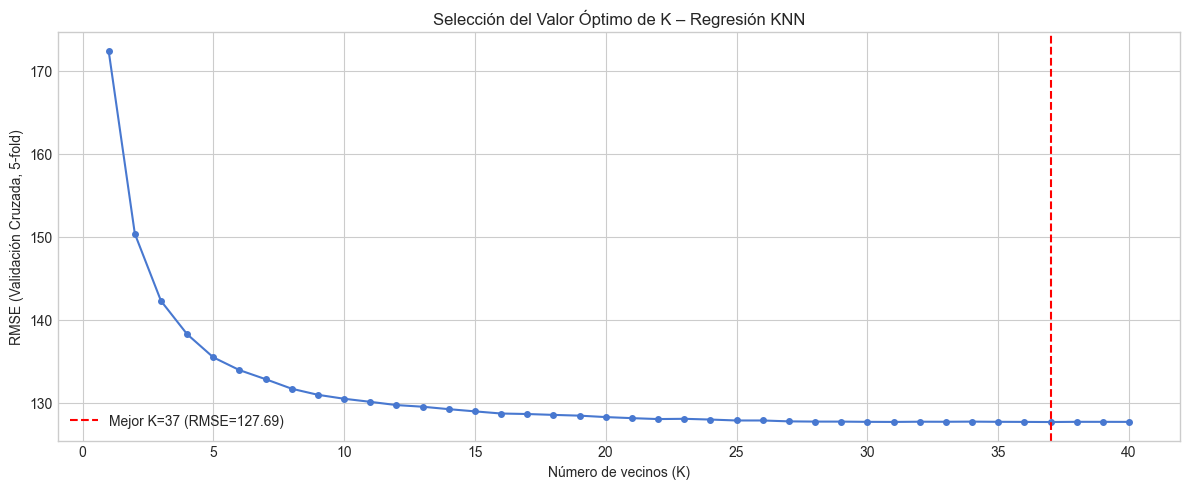

Mejor K encontrado: 37
RMSE con validación cruzada: 127.69

Referencia: sqrt(n) = 205.94 ≈ 205 vecinos


In [6]:
# Exploración inicial del mejor K
k_values = range(1, 41)
cv_rmse_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_reg, cv=5,
                            scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    cv_rmse_scores.append(rmse)

# Gráfico de RMSE vs K
plt.figure(figsize=(12, 5))
plt.plot(k_values, cv_rmse_scores, 'o-', markersize=4, linewidth=1.5)
best_k_idx = np.argmin(cv_rmse_scores)
plt.axvline(x=k_values[best_k_idx], color='red', linestyle='--',
            label=f'Mejor K={k_values[best_k_idx]} (RMSE={cv_rmse_scores[best_k_idx]:.2f})')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('RMSE (Validación Cruzada, 5-fold)')
plt.title('Selección del Valor Óptimo de K – Regresión KNN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Mejor K encontrado: {k_values[best_k_idx]}')
print(f'RMSE con validación cruzada: {cv_rmse_scores[best_k_idx]:.2f}')
print(f'\nReferencia: sqrt(n) = {math.sqrt(len(X_train)):.2f} ≈ {int(math.sqrt(len(X_train)))} vecinos')

### Búsqueda de Hiperparámetros con GridSearchCV



In [7]:
# GridSearch con múltiples hiperparámetros
param_grid_reg = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1: Manhattan, p=2: Euclidiana
}

grid_search_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_reg,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)
grid_search_reg.fit(X_train_scaled, y_train_reg)

print(f'Mejores hiperparámetros: {grid_search_reg.best_params_}')
print(f'Mejor RMSE (CV): {np.sqrt(-grid_search_reg.best_score_):.2f}')

Mejores hiperparámetros: {'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}
Mejor RMSE (CV): 127.10


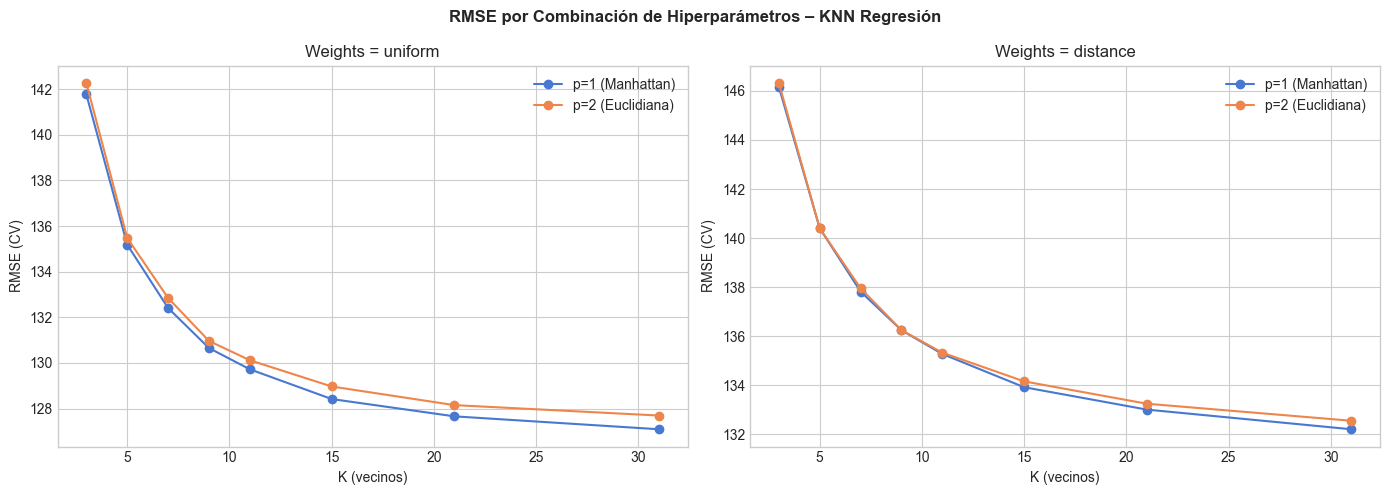

In [8]:
# Visualizar resultados del GridSearch
results_reg = pd.DataFrame(grid_search_reg.cv_results_)
results_reg['rmse'] = np.sqrt(-results_reg['mean_test_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for weight in ['uniform', 'distance']:
    for p_val in [1, 2]:
        mask = (results_reg['param_weights'] == weight) & (results_reg['param_p'] == p_val)
        label = f'{weight}, {"Manhattan" if p_val == 1 else "Euclidiana"}'
        subset = results_reg[mask].sort_values('param_n_neighbors')
        ax_idx = 0 if weight == 'uniform' else 1
        axes[ax_idx].plot(subset['param_n_neighbors'], subset['rmse'],
                         'o-', label=f'p={p_val} ({"Manhattan" if p_val==1 else "Euclidiana"})')

for i, w in enumerate(['uniform', 'distance']):
    axes[i].set_xlabel('K (vecinos)')
    axes[i].set_ylabel('RMSE (CV)')
    axes[i].set_title(f'Weights = {w}')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('RMSE por Combinación de Hiperparámetros – KNN Regresión', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Modelo final de regresión con mejores hiperparámetros
best_knn_reg = grid_search_reg.best_estimator_

# Predicciones
y_pred_train_knn = best_knn_reg.predict(X_train_scaled)
y_pred_test_knn = best_knn_reg.predict(X_test_scaled)

print('=== PREDICCIONES KNN REGRESIÓN ===')
print(f'Hiperparámetros: {grid_search_reg.best_params_}')

comparison = pd.DataFrame({
    'Precio Real ($)': y_test_reg.values[:15],
    'Predicción KNN ($)': y_pred_test_knn[:15].round(2),
    'Error Absoluto ($)': np.abs(y_test_reg.values[:15] - y_pred_test_knn[:15]).round(2)
})
print('\nPrimeras 15 predicciones vs valores reales:')
print(comparison.to_string(index=False))

=== PREDICCIONES KNN REGRESIÓN ===
Hiperparámetros: {'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}

Primeras 15 predicciones vs valores reales:
 Precio Real ($)  Predicción KNN ($)  Error Absoluto ($)
           112.0              293.52              181.52
           110.0              313.55              203.55
           111.0              127.00               16.00
           800.0              349.00              451.00
           190.0              174.42               15.58
            80.0              109.61               29.61
            97.0              126.19               29.19
            66.0               69.58                3.58
            63.0               74.74               11.74
           310.0              252.23               57.77
           880.0              205.58              674.42
           136.0              208.94               72.94
           190.0              284.03               94.03
           132.0              247.35              115.3

---
## 2. Análisis de Resultados del Modelo de Regresión KNN


In [10]:
# Métricas en entrenamiento y prueba
def calc_metrics_reg(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred)
    }

metrics_train = calc_metrics_reg(y_train_reg, y_pred_train_knn)
metrics_test = calc_metrics_reg(y_test_reg, y_pred_test_knn)

print('=== MÉTRICAS DE REGRESIÓN – KNN ===')
print(f'\n{"Métrica":<10} {"Entrenamiento":>15} {"Prueba":>15}')
print('-' * 42)
for metric in ['MSE', 'RMSE', 'MAE', 'R²']:
    fmt = '.4f' if metric == 'R²' else '.2f'
    print(f'{metric:<10} {metrics_train[metric]:>15{fmt}} {metrics_test[metric]:>15{fmt}}')

gap = metrics_train['R²'] - metrics_test['R²']
print(f'\nGap R² (Train - Test): {gap:.4f}')
if gap > 0.1:
    print('Posible sobreajuste: la diferencia entre entrenamiento y prueba es considerable.')
else:
    print('El modelo generaliza razonablemente bien.')

print(f'\nInterpretación:')
print(f'- El modelo KNN explica el {metrics_test["R²"]*100:.1f}% de la varianza del precio en el conjunto de prueba.')
print(f'- En promedio, se equivoca por ${metrics_test["MAE"]:.2f} por noche.')
print(f'- El RMSE de ${metrics_test["RMSE"]:.2f} indica que hay algunos errores grandes que penalizan más.')

=== MÉTRICAS DE REGRESIÓN – KNN ===

Métrica      Entrenamiento          Prueba
------------------------------------------
MSE               15112.90        16704.30
RMSE                122.93          129.25
MAE                  84.61           88.24
R²                  0.4765          0.4189

Gap R² (Train - Test): 0.0576
El modelo generaliza razonablemente bien.

Interpretación:
- El modelo KNN explica el 41.9% de la varianza del precio en el conjunto de prueba.
- En promedio, se equivoca por $88.24 por noche.
- El RMSE de $129.25 indica que hay algunos errores grandes que penalizan más.


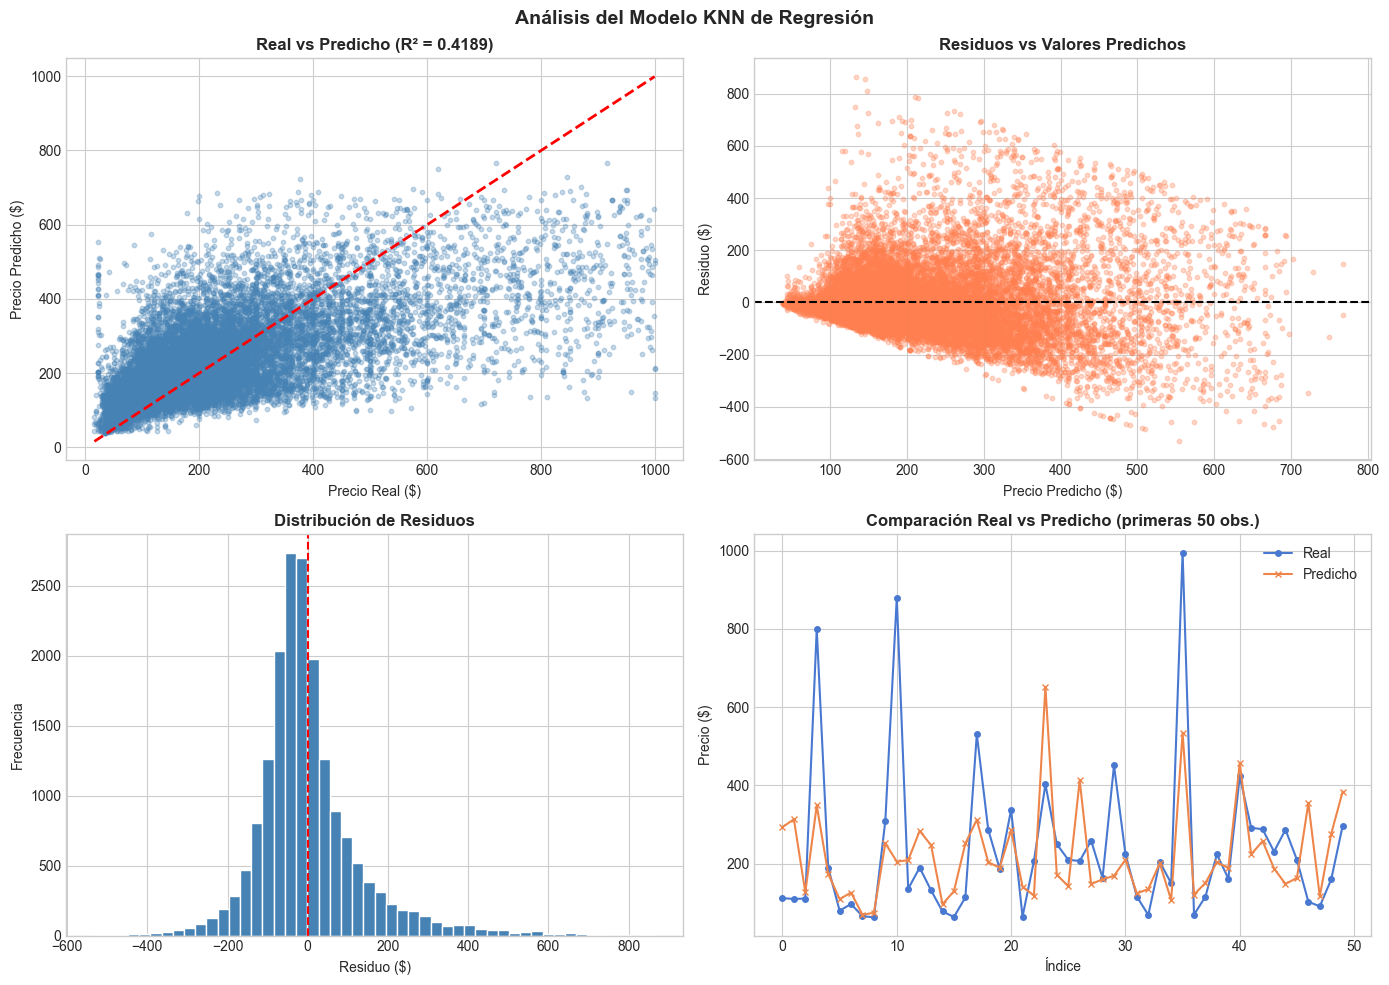

In [11]:
# Visualizaciones del modelo de regresión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Valores reales vs predichos
axes[0, 0].scatter(y_test_reg, y_pred_test_knn, alpha=0.3, s=10, color='steelblue')
axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()],
               [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Precio Real ($)')
axes[0, 0].set_ylabel('Precio Predicho ($)')
axes[0, 0].set_title(f'Real vs Predicho (R² = {metrics_test["R²"]:.4f})', fontweight='bold')

# 2. Residuos vs Predichos
residuals = y_test_reg.values - y_pred_test_knn
axes[0, 1].scatter(y_pred_test_knn, residuals, alpha=0.3, s=10, color='coral')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Precio Predicho ($)')
axes[0, 1].set_ylabel('Residuo ($)')
axes[0, 1].set_title('Residuos vs Valores Predichos', fontweight='bold')

# 3. Distribución de residuos
axes[1, 0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Residuo ($)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos', fontweight='bold')

# 4. Comparación real vs predicho (primeras 50 observaciones)
n_show = 50
axes[1, 1].plot(range(n_show), y_test_reg.values[:n_show], 'o-', label='Real', markersize=4)
axes[1, 1].plot(range(n_show), y_pred_test_knn[:n_show], 'x-', label='Predicho', markersize=4)
axes[1, 1].set_xlabel('Índice')
axes[1, 1].set_ylabel('Precio ($)')
axes[1, 1].set_title('Comparación Real vs Predicho (primeras 50 obs.)', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Análisis del Modelo KNN de Regresión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Comparación con Modelos de Regresión de Entregas Anteriores


In [12]:
# Re-entrenar todos los modelos anteriores con los MISMOS datos
modelos_reg = {}

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
modelos_reg['Regresión Lineal'] = lr.predict(X_test)

# 2. Árbol de Regresión (con tuneo básico)
dt_reg = DecisionTreeRegressor(random_state=SEED, max_depth=10)
dt_reg.fit(X_train, y_train_reg)
modelos_reg['Árbol de Regresión'] = dt_reg.predict(X_test)

# 3. Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
modelos_reg['Random Forest'] = rf_reg.predict(X_test)

# 4. Naive Bayes (como "regresión")
nb_reg = GaussianNB()
nb_reg.fit(X_train, y_train_reg)
modelos_reg['Naive Bayes'] = nb_reg.predict(X_test)

# 5. KNN (mejor modelo)
modelos_reg['KNN'] = y_pred_test_knn

print('Todos los modelos entrenados con los mismos datos.')

Todos los modelos entrenados con los mismos datos.


In [13]:
# Tabla comparativa de regresión
comparacion_reg = []
for nombre, y_pred in modelos_reg.items():
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    comparacion_reg.append({
        'Modelo': nombre,
        'RMSE ($)': round(rmse, 2),
        'MAE ($)': round(mae, 2),
        'R²': round(r2, 4)
    })

df_comp_reg = pd.DataFrame(comparacion_reg).sort_values('RMSE ($)')
print('=== COMPARACIÓN DE MODELOS DE REGRESIÓN ===')
print('(Todos con los mismos datos de entrenamiento y prueba)\n')
print(df_comp_reg.to_string(index=False))

mejor_reg = df_comp_reg.iloc[0]
print(f'\nMejor modelo de regresión: {mejor_reg["Modelo"]}')
print(f'  RMSE: ${mejor_reg["RMSE ($)"]:.2f}')
print(f'  MAE: ${mejor_reg["MAE ($)"]:.2f}')
print(f'  R²: {mejor_reg["R²"]:.4f}')

=== COMPARACIÓN DE MODELOS DE REGRESIÓN ===
(Todos con los mismos datos de entrenamiento y prueba)

            Modelo  RMSE ($)  MAE ($)      R²
     Random Forest    126.68    86.27  0.4417
               KNN    129.25    88.24  0.4189
Árbol de Regresión    131.41    88.54  0.3993
  Regresión Lineal    137.16    94.51  0.3456
       Naive Bayes    324.25   231.69 -2.6572

Mejor modelo de regresión: Random Forest
  RMSE: $126.68
  MAE: $86.27
  R²: 0.4417


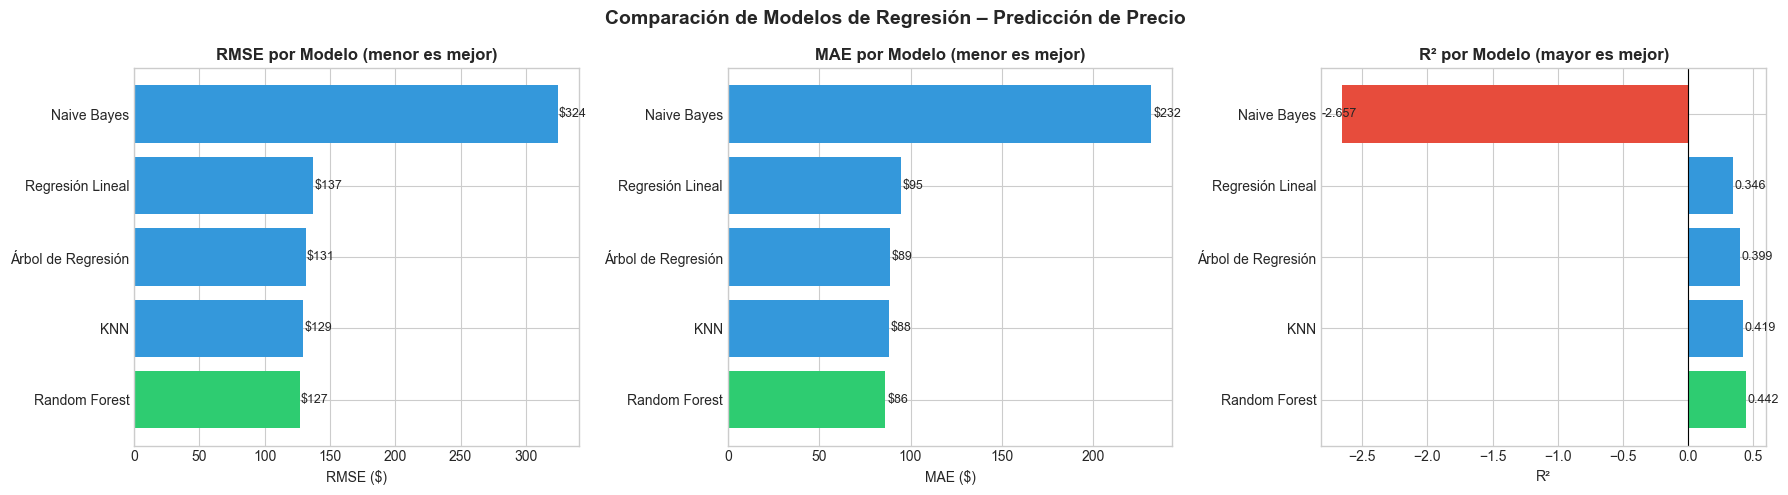

In [14]:
# Gráfico comparativo de modelos de regresión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_nombres = df_comp_reg['Modelo'].values
colores = ['#2ecc71' if m == mejor_reg['Modelo'] else '#3498db' for m in modelos_nombres]

# RMSE
bars1 = axes[0].barh(modelos_nombres, df_comp_reg['RMSE ($)'].values, color=colores)
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('RMSE por Modelo (menor es mejor)', fontweight='bold')
for bar, val in zip(bars1, df_comp_reg['RMSE ($)'].values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
               f'${val:.0f}', va='center', fontsize=9)

# MAE
bars2 = axes[1].barh(modelos_nombres, df_comp_reg['MAE ($)'].values, color=colores)
axes[1].set_xlabel('MAE ($)')
axes[1].set_title('MAE por Modelo (menor es mejor)', fontweight='bold')
for bar, val in zip(bars2, df_comp_reg['MAE ($)'].values):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
               f'${val:.0f}', va='center', fontsize=9)

# R²
r2_vals = df_comp_reg['R²'].values
colores_r2 = ['#2ecc71' if m == mejor_reg['Modelo'] else '#e74c3c' if r < 0 else '#3498db'
              for m, r in zip(modelos_nombres, r2_vals)]
bars3 = axes[2].barh(modelos_nombres, r2_vals, color=colores_r2)
axes[2].set_xlabel('R²')
axes[2].set_title('R² por Modelo (mayor es mejor)', fontweight='bold')
axes[2].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for bar, val in zip(bars3, r2_vals):
    axes[2].text(bar.get_width() + 0.01 if val >= 0 else bar.get_width() - 0.15,
               bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos de Regresión – Predicción de Precio',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de la Comparación de Regresión

La tabla y las gráficas muestran claramente el desempeño relativo de cada algoritmo para predecir el precio continuo de propiedades Airbnb:

- **Regresión Lineal** asume una relación lineal entre features y precio. Si la relación real es no lineal, su capacidad predictiva es limitada.
- **Árboles de Regresión** pueden capturar relaciones no lineales pero tienden a sobreajustar si no se controla la profundidad.
- **Random Forest** mejora sobre árboles individuales al promediar múltiples árboles, reduciendo la varianza.
- **Naive Bayes** no está diseñado para regresión continua; trata cada precio como una clase, lo que produce resultados pobres.
- **KNN** captura patrones locales en los datos sin asumir una forma funcional específica. La normalización y la elección correcta de K son clave para su desempeño.

---
## 4. Modelo de Clasificación KNN – Categorías de Precio


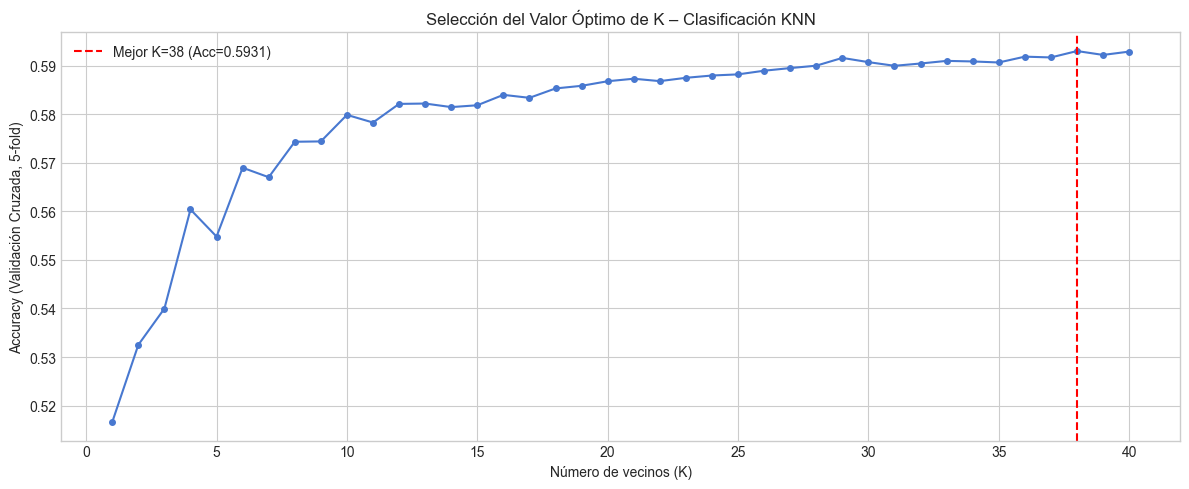

Mejor K para clasificación: 38
Accuracy con validación cruzada: 0.5931


In [15]:
# Exploración de K para clasificación
k_values_clf = range(1, 41)
cv_accuracy_scores = []

for k in k_values_clf:
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_clf, X_train_scaled, y_train_clf, cv=5, scoring='accuracy')
    cv_accuracy_scores.append(scores.mean())

# Gráfico de Accuracy vs K
plt.figure(figsize=(12, 5))
plt.plot(k_values_clf, cv_accuracy_scores, 'o-', markersize=4, linewidth=1.5)
best_k_clf_idx = np.argmax(cv_accuracy_scores)
plt.axvline(x=k_values_clf[best_k_clf_idx], color='red', linestyle='--',
            label=f'Mejor K={k_values_clf[best_k_clf_idx]} (Acc={cv_accuracy_scores[best_k_clf_idx]:.4f})')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Accuracy (Validación Cruzada, 5-fold)')
plt.title('Selección del Valor Óptimo de K – Clasificación KNN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Mejor K para clasificación: {k_values_clf[best_k_clf_idx]}')
print(f'Accuracy con validación cruzada: {cv_accuracy_scores[best_k_clf_idx]:.4f}')

In [16]:
# GridSearch para clasificación
param_grid_clf = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search_clf = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)
grid_search_clf.fit(X_train_scaled, y_train_clf)

print(f'Mejores hiperparámetros: {grid_search_clf.best_params_}')
print(f'Mejor Accuracy (CV): {grid_search_clf.best_score_:.4f}')

Mejores hiperparámetros: {'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}
Mejor Accuracy (CV): 0.5944


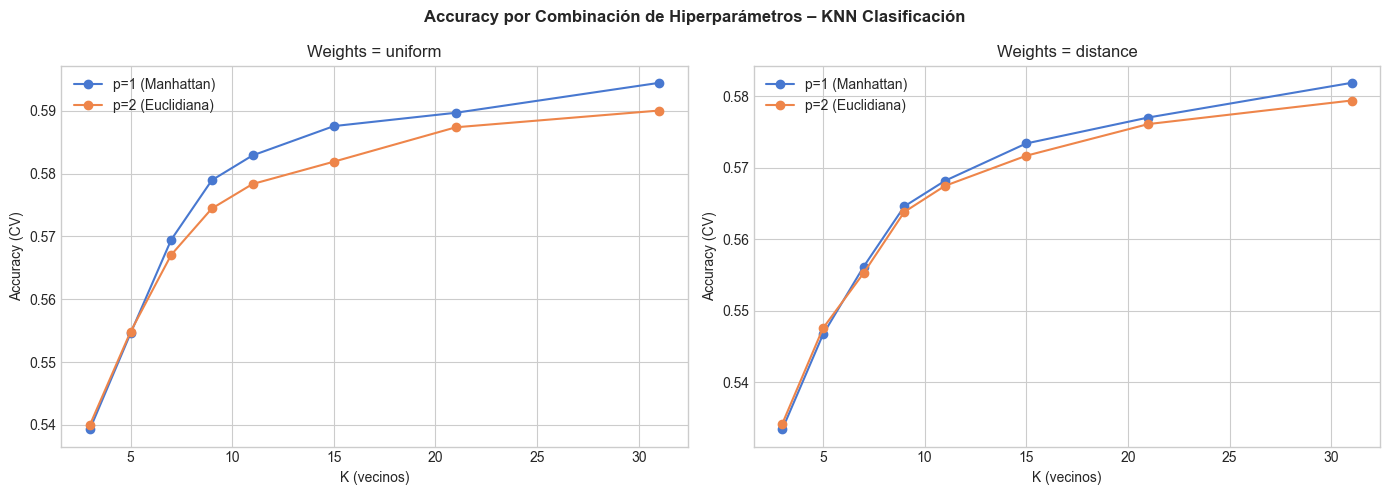

In [17]:
# Visualizar resultados del GridSearch de clasificación
results_clf = pd.DataFrame(grid_search_clf.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for weight in ['uniform', 'distance']:
    for p_val in [1, 2]:
        mask = (results_clf['param_weights'] == weight) & (results_clf['param_p'] == p_val)
        subset = results_clf[mask].sort_values('param_n_neighbors')
        ax_idx = 0 if weight == 'uniform' else 1
        axes[ax_idx].plot(subset['param_n_neighbors'], subset['mean_test_score'],
                         'o-', label=f'p={p_val} ({"Manhattan" if p_val==1 else "Euclidiana"})')

for i, w in enumerate(['uniform', 'distance']):
    axes[i].set_xlabel('K (vecinos)')
    axes[i].set_ylabel('Accuracy (CV)')
    axes[i].set_title(f'Weights = {w}')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Accuracy por Combinación de Hiperparámetros – KNN Clasificación', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Eficiencia del Modelo en el Conjunto de Prueba


### 5.1 Eficiencia del Modelo de Regresión KNN

In [18]:
# Eficiencia de regresión en conjunto de prueba
print('=== EFICIENCIA DEL MODELO KNN – REGRESIÓN (Conjunto de Prueba) ===')
print(f'Hiperparámetros: {grid_search_reg.best_params_}')
print(f'\nMétricas en conjunto de PRUEBA:')
print(f'  MSE  : ${metrics_test["MSE"]:,.2f}')
print(f'  RMSE : ${metrics_test["RMSE"]:,.2f}')
print(f'  MAE  : ${metrics_test["MAE"]:,.2f}')
print(f'  R²   : {metrics_test["R²"]:.4f}')

print(f'\nMétricas en conjunto de ENTRENAMIENTO:')
print(f'  MSE  : ${metrics_train["MSE"]:,.2f}')
print(f'  RMSE : ${metrics_train["RMSE"]:,.2f}')
print(f'  MAE  : ${metrics_train["MAE"]:,.2f}')
print(f'  R²   : {metrics_train["R²"]:.4f}')

print(f'\nAnálisis de generalización:')
print(f'  Gap R² (Train - Test): {metrics_train["R²"] - metrics_test["R²"]:.4f}')
print(f'  Gap RMSE (Test - Train): ${metrics_test["RMSE"] - metrics_train["RMSE"]:,.2f}')

=== EFICIENCIA DEL MODELO KNN – REGRESIÓN (Conjunto de Prueba) ===
Hiperparámetros: {'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}

Métricas en conjunto de PRUEBA:
  MSE  : $16,704.30
  RMSE : $129.25
  MAE  : $88.24
  R²   : 0.4189

Métricas en conjunto de ENTRENAMIENTO:
  MSE  : $15,112.90
  RMSE : $122.93
  MAE  : $84.61
  R²   : 0.4765

Análisis de generalización:
  Gap R² (Train - Test): 0.0576
  Gap RMSE (Test - Train): $6.31


### 5.2 Eficiencia del Modelo de Clasificación KNN

In [19]:
# Modelo final de clasificación
best_knn_clf = grid_search_clf.best_estimator_

# Predicciones en test
y_pred_train_clf_knn = best_knn_clf.predict(X_train_scaled)
y_pred_test_clf_knn = best_knn_clf.predict(X_test_scaled)

# Accuracy
acc_train = accuracy_score(y_train_clf, y_pred_train_clf_knn)
acc_test = accuracy_score(y_test_clf, y_pred_test_clf_knn)

print('=== EFICIENCIA DEL MODELO KNN – CLASIFICACIÓN ===')
print(f'Hiperparámetros: {grid_search_clf.best_params_}')
print(f'\nAccuracy en entrenamiento: {acc_train:.4f}')
print(f'Accuracy en prueba: {acc_test:.4f}')
print(f'Gap (Train - Test): {acc_train - acc_test:.4f}')

=== EFICIENCIA DEL MODELO KNN – CLASIFICACIÓN ===
Hiperparámetros: {'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}

Accuracy en entrenamiento: 0.6217
Accuracy en prueba: 0.5914
Gap (Train - Test): 0.0303


In [20]:
# Reporte de clasificación detallado
print('=== REPORTE DE CLASIFICACIÓN KNN (Conjunto de Prueba) ===\n')
print(classification_report(y_test_clf, y_pred_test_clf_knn,
                           target_names=['barata', 'media', 'cara']))

=== REPORTE DE CLASIFICACIÓN KNN (Conjunto de Prueba) ===

              precision    recall  f1-score   support

      barata       0.62      0.72      0.67      6264
       media       0.65      0.65      0.65      5693
        cara       0.49      0.41      0.45      6220

    accuracy                           0.59     18177
   macro avg       0.59      0.59      0.59     18177
weighted avg       0.58      0.59      0.59     18177



Matriz de Confusión:
              Pred: Barata  Pred: Media  Pred: Cara
Real: Barata          4487         1346         431
Real: Media           2048         2579        1593
Real: Cara             687         1323        3683


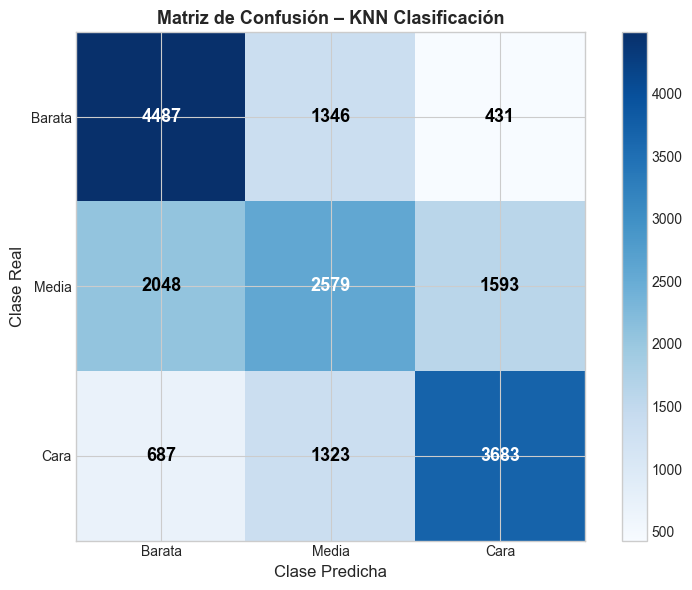


Análisis de la Matriz de Confusión:
  Barata: 4487/6264 correctos (71.6%)
    → Confundido con Media: 1346 veces (21.5%)
    → Confundido con Cara: 431 veces (6.9%)
  Media: 2579/6220 correctos (41.5%)
    → Confundido con Barata: 2048 veces (32.9%)
    → Confundido con Cara: 1593 veces (25.6%)
  Cara: 3683/5693 correctos (64.7%)
    → Confundido con Media: 1323 veces (23.2%)
    → Confundido con Barata: 687 veces (12.1%)


In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_test_clf_knn, labels=['barata', 'media', 'cara'])
cm_df = pd.DataFrame(cm,
    index=['Real: Barata', 'Real: Media', 'Real: Cara'],
    columns=['Pred: Barata', 'Pred: Media', 'Pred: Cara'])

print('Matriz de Confusión:')
print(cm_df)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Barata', 'Media', 'Cara']
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(clases)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(clases)
ax.set_xlabel('Clase Predicha', fontsize=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_title('Matriz de Confusión – KNN Clasificación', fontsize=13, fontweight='bold')
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
               fontsize=13, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

# Análisis de la matriz
print('\nAnálisis de la Matriz de Confusión:')
for i, clase in enumerate(clases):
    total_real = cm[i].sum()
    correctos = cm[i, i]
    print(f'  {clase}: {correctos}/{total_real} correctos ({correctos/total_real*100:.1f}%)')
    errores = [(clases[j], cm[i, j]) for j in range(3) if j != i and cm[i, j] > 0]
    for clase_err, n_err in sorted(errores, key=lambda x: -x[1]):
        print(f'    → Confundido con {clase_err}: {n_err} veces ({n_err/total_real*100:.1f}%)')

In [22]:
# Comparación rápida de clasificación: KNN vs modelos anteriores
modelos_clf = {}

# Árbol de Decisión
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=SEED)
dt_clf.fit(X_train, y_train_clf)
modelos_clf['Árbol de Decisión'] = dt_clf.predict(X_test)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_clf.fit(X_train, y_train_clf)
modelos_clf['Random Forest'] = rf_clf.predict(X_test)

# Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train_clf)
modelos_clf['Naive Bayes'] = nb_clf.predict(X_test)

# KNN
modelos_clf['KNN'] = y_pred_test_clf_knn

# Tabla comparativa
comparacion_clf = []
for nombre, y_pred in modelos_clf.items():
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average='weighted')
    rec = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')
    comparacion_clf.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision (W)': round(prec, 4),
        'Recall (W)': round(rec, 4),
        'F1-Score (W)': round(f1, 4)
    })

df_comp_clf = pd.DataFrame(comparacion_clf).sort_values('Accuracy', ascending=False)
print('=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===')
print('(Todos con los mismos datos de entrenamiento y prueba)\n')
print(df_comp_clf.to_string(index=False))

mejor_clf = df_comp_clf.iloc[0]
print(f'\nMejor modelo de clasificación: {mejor_clf["Modelo"]}')
print(f'  Accuracy: {mejor_clf["Accuracy"]:.4f}')
print(f'  F1-Score: {mejor_clf["F1-Score (W)"]:.4f}')

=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===
(Todos con los mismos datos de entrenamiento y prueba)

           Modelo  Accuracy  Precision (W)  Recall (W)  F1-Score (W)
    Random Forest    0.6054         0.5986      0.6054        0.6005
Árbol de Decisión    0.5948         0.5890      0.5948        0.5897
              KNN    0.5914         0.5844      0.5914        0.5856
      Naive Bayes    0.5438         0.5457      0.5438        0.5305

Mejor modelo de clasificación: Random Forest
  Accuracy: 0.6054
  F1-Score: 0.6005


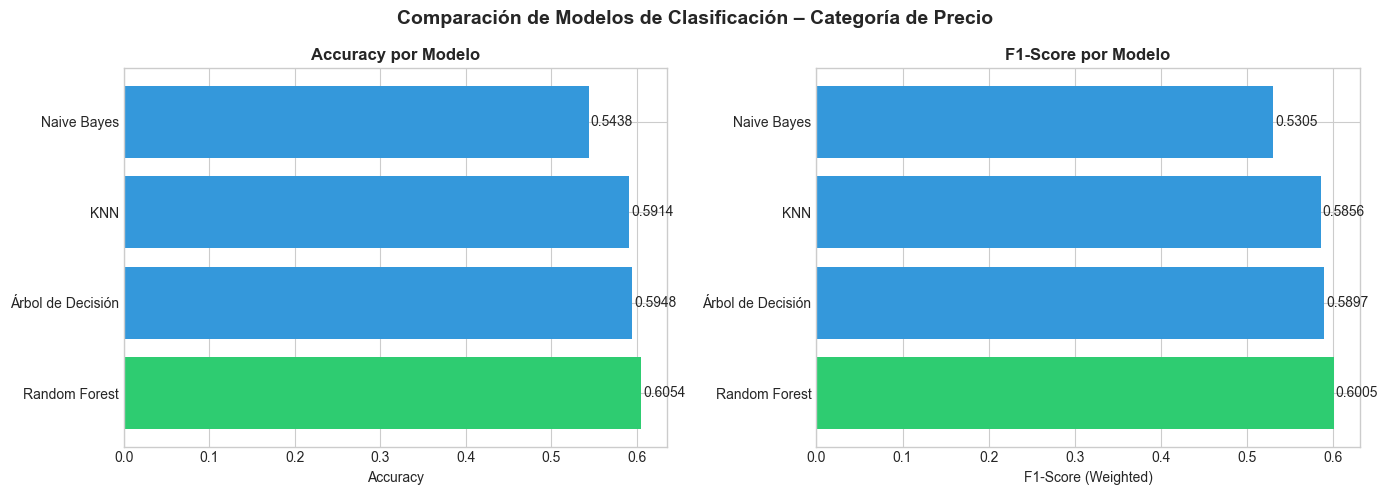

In [23]:
# Gráfico comparativo de clasificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_clf_nombres = df_comp_clf['Modelo'].values
colores_clf = ['#2ecc71' if m == mejor_clf['Modelo'] else '#3498db' for m in modelos_clf_nombres]

# Accuracy
bars1 = axes[0].barh(modelos_clf_nombres, df_comp_clf['Accuracy'].values, color=colores_clf)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy por Modelo', fontweight='bold')
for bar, val in zip(bars1, df_comp_clf['Accuracy'].values):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=10)

# F1-Score
bars2 = axes[1].barh(modelos_clf_nombres, df_comp_clf['F1-Score (W)'].values, color=colores_clf)
axes[1].set_xlabel('F1-Score (Weighted)')
axes[1].set_title('F1-Score por Modelo', fontweight='bold')
for bar, val in zip(bars2, df_comp_clf['F1-Score (W)'].values):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Comparación de Modelos de Clasificación – Categoría de Precio',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()